# Implementing The Cnn In Tensorflow

### ---Data Loading

Here we're using a cusom function to load datas from binary mnist files

In [10]:
import struct
import numpy as np
import os


def load_idx(filename):
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(num, rows, cols)

def load_labels(filename):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

# Load data
loc_path = os.getcwd()
x_train_full = load_idx(loc_path + '\\Datasets\\Images_MNIST\\train-images.idx3-ubyte') / 255.0
y_train_full = load_labels(loc_path + '\\Datasets\\Images_MNIST\\train-labels.idx1-ubyte')

x_test = load_idx(loc_path + '\\Datasets\\Images_MNIST\\t10k-images.idx3-ubyte') / 255.0
y_test = load_labels(loc_path + '\\Datasets\\Images_MNIST\\t10k-labels.idx1-ubyte')

# Use a subset for quick training
x_train = x_train_full#[:1000]
y_train = y_train_full#[:1000]


### Data Augmentation and model creation

**Data Augmentation :** Is the process where we apply some random variation to a data
    that could happen in real life to improve generalization, in other words we are adding some noise to the original datas.

**Cnn Creation :** Is an image reconition model, that exploit features and spatial 
features of images. Here we're creating one with:  

- A convolutional layer with 32 filters(kernels), each filter is like an eye  
    which will observe the image from a different point of view; this layer will extract general features. and keeps only some by it's relu decision
- A Pooling Layer that reduces dimensions of the image in a simpler representation
- Another Convolutionary layer thar extracts more deep features.
- A flattening layer that prepares the "image" for the dense layer.
- A dropout layer that shuts off some neurons randomly in this way   
    the network will not rely only on certain neurons for a prediction and will   
    be more stable, we put a dropout after the flatten because it one of the biggest  
    layers with a lot of features, so une of the most sensible to overfitting.
- A dense layer, with relu.
- Another Dropout
- Another Dense
- Another Dropout
- Softmax does the final prediction for the model

    




In [11]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from keras.layers import RandomFlip, RandomRotation, RandomZoom , RandomTranslation, RandomContrast , RandomBrightness



data_augmentation = keras.Sequential([
    #RandomFlip("horizontal_and_vertical"), # You can choose "horizontal", "vertical", or "horizontal_and_vertical"
    RandomRotation(0.15), # 15% rotation
    RandomZoom(0.1),# 20% zoom
    RandomTranslation(0.1, 0.1), # 10% translation
])


model = Sequential(
    [
        data_augmentation,
        Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1), kernel_regularizer=keras.regularizers.l2(0.001)),
        MaxPooling2D((2,2)),
        Conv2D(64, kernel_size =(3,3), activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        Flatten(),
        Dropout(0.2),
        Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(10,activation= "softmax")       
    ]

)

### Setting model optimizer and evaluation

Here we evaluate the model, with:

**Adam :** is an adaptive, momentum-based optimizer that balances speed and stability in training neural networks. Like gradient descent but the   
            learning rate automatically increases or decreases

**Sparse Categorical Cross-Entropy :** Sparse categorical crossentropy is a loss function for multi-class classification.

**Accuracy :** Accuracy in deep learning is the proportion of correct predictions made by a model out of all predictions.  
 It’s one of the most common evaluation metrics for classification tasks, but it has limitations when datasets are imbalanced.

In [12]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
              )
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Training and callbacks

Callbacks are functions, that get called after each each epoc, here:

**Early Stopping :** Stop the model after tot epochs if there are no impovements in the loss
**Model Checkpoints :** Saves the best model after each epoch if is better than the previous

Tranining is the process were the model learn the relationships between the inputs and outputs and trys to emulate it's relationships, about the parameters we can choose in the trainig we have :

**Number of epochs :** The number of times the training set gets learned by the model.

**Bach size :** The number of samples that gets fed in the model in one learning operation inside an epoch.



In [13]:
import keras.callbacks as callbacks

callbacks =[ 
    callbacks.EarlyStopping(monitor="loss",patience=3,restore_best_weights=True),
    callbacks.ModelCheckpoint("Models//best_Mnist_Cnn.keras",monitor="loss" ,save_best_only=True)

]

history = model.fit(x_train, y_train, epochs=4, batch_size=32, callbacks=callbacks)

Epoch 1/4


ValueError: Input 0 of layer "conv2d_2" is incompatible with the layer: expected min_ndim=4, found ndim=3. Full shape received: (32, 28, 28)

### Evaluation

Evaluation on the test set to avoid biased evaluations.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("Test accuracy:", int(test_acc))

313/313 - 2s - 7ms/step - accuracy: 0.9807 - loss: 0.1819
Test accuracy: 0


### Visualizations of the filters(mentioned early)

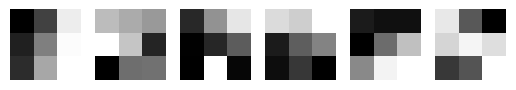

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

layer = model.layers[0]   # first Conv2D layer
filters, biases = layer.get_weights()

# Plot first 6 filters
n_filters = 6
for i in range(n_filters):
    f = filters[:, :, 0, i]   # take channel 0
    plt.subplot(1, n_filters, i+1)
    plt.imshow(f, cmap='gray')
    plt.axis('off')
plt.show()


### Are CNN Black Boxes?

**Kinda.**

Convolutional Neural Networks (CNNs) are often called *black boxes* because:
- They contain millions of parameters that are hard to interpret directly.
- We see inputs (images) and outputs (predictions), but the internal decision process isn’t obvious.
- Filters and activations don’t always map neatly to human‑understandable concepts.

But CNNs are **not completely opaque**:
- We can **visualize filters** (`layer.get_weights()`) to see what patterns are being learned.
- We can **inspect feature maps** (activations) to understand how an image transforms layer by layer.
- Tools like **Grad‑CAM** and **saliency maps** highlight which pixels influenced a decision.
- Early layers tend to learn simple features (edges, textures), while deeper layers capture complex shapes and patterns.